In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/H1_genomic.csv")

In [3]:
len(df['date'].unique())

4988

In [4]:
len(df)

55098

In [5]:
df[df['date'] == 10575000]

,date,feat0,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,target_7,target_8,target_9,target_10,target_11,target_12,target_13,target_14,target_15,target_16
0,10575000,0.000000,0.007210,0.004853,0.002320,0.003769,0.014969,0.36846,0.0,-0.447726,...,0.000168,0.016228,0.030838,0.049020,0.070511,0.112708,0.156251,0.150135,0.132198,0.161733
972,10575000,0.636229,0.459187,0.611993,0.495039,0.376887,0.699174,0.34352,1.0,-3.078930,...,0.000000,0.001150,0.015084,0.054618,0.119768,0.183022,0.203242,0.185093,0.141564,0.096459
3438,10575000,0.762716,0.524391,0.626952,0.927179,0.552453,0.740815,0.40354,2.0,0.450971,...,0.093834,0.079213,0.062393,0.047384,0.037146,0.025211,0.009662,0.001722,0.000736,0.000399
5103,10575000,0.597025,0.404721,0.626916,0.512455,0.379019,0.607241,0.35342,1.0,-2.625950,...,0.002059,0.015226,0.048850,0.096757,0.148431,0.187085,0.184096,0.147404,0.101941,0.068151
10255,10575000,0.899969,0.482188,0.820037,1.103545,0.515156,0.692151,0.39566,1.0,-0.033724,...,0.058822,0.065879,0.076025,0.083006,0.082646,0.068692,0.040500,0.017283,0.010368,0.011988
11542,10575000,1.019209,1.260153,0.699073,1.277779,0.525442,0.807558,0.50216,1.0,1.246700,...,0.125783,0.105187,0.072819,0.040680,0.017300,0.005460,0.000801,0.000349,0.000391,0.000474
16137,10575000,1.028971,0.664832,1.850976,1.016151,2.029384,0.536754,0.52886,7.0,2.852740,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013975,0.037017
17259,10575000,0.657379,0.486359,0.871589,0.570640,0.348468,0.961448,0.44132,2.0,-0.708778,...,0.082434,0.115505,0.140640,0.150870,0.149460,0.130723,0.089537,0.045881,0.018192,0.005567
18864,10575000,0.867967,2.613765,0.654278,1.450473,1.467367,0.665714,0.47364,2.0,1.961680,...,0.100091,0.047958,0.010864,0.000000,0.000000,0.000000,0.001047,0.001726,0.001047,0.000000
24235,10575000,0.840951,1.155461,0.575690,0.860685,0.366702,0.756372,0.48060,2.0,-1.094250,...,0.093602,0.122631,0.141703,0.146910,0.140258,0.115504,0.074410,0.035745,0.013782,0.004374


In [6]:
y_pred = np.load('../results/genomic_multitarget_informer/pred.npy')
y_true = np.load('../results/genomic_multitarget_informer/true.npy')

y_pred = np.squeeze(y_pred)  # This will result in shape (16, 11008)
y_true = np.squeeze(y_true)  # This will result in shape (16, 11008)


In [7]:
y_true[0],y_pred[0]

(array([0.        , 0.00077949, 0.00846107, 0.02518239, 0.05393489,
        0.08618726, 0.11187017, 0.12757742, 0.13308376, 0.12812221,
        0.11753399, 0.09762023, 0.06243226, 0.03058418, 0.01246468,
        0.00416598], dtype=float32),
 array([-0.00251516,  0.00443431,  0.01594345,  0.0315832 ,  0.05316637,
         0.07331938,  0.09499919,  0.11707269,  0.12934609,  0.13026102,
         0.12448692,  0.10519999,  0.07020934,  0.03389155,  0.01173438,
         0.00392879], dtype=float32))

In [8]:
len(y_true),len(y_pred)

(11008, 11008)

In [9]:
s_phase_labels = [f"S{i+1}" for i in range(16)]

In [10]:
def plot_heatmap(data, title, xlabel, ylabel, cmap="viridis"):
    plt.figure(figsize=(12, 8))
    sns.heatmap(data, cmap=cmap, cbar=True, xticklabels=100, yticklabels=s_phase_labels)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

In [12]:
y_true_transposed = y_true.T  # Shape: (16, num_bins)
y_pred_transposed = y_pred.T  # Shape: (16, num_bins)

num_bins = y_true_transposed.shape[1] // 1000
kbin_labels = [f"{i+1} kb" for i in range(num_bins)]

kbin_labels

['1 kb',
 '2 kb',
 '3 kb',
 '4 kb',
 '5 kb',
 '6 kb',
 '7 kb',
 '8 kb',
 '9 kb',
 '10 kb',
 '11 kb']

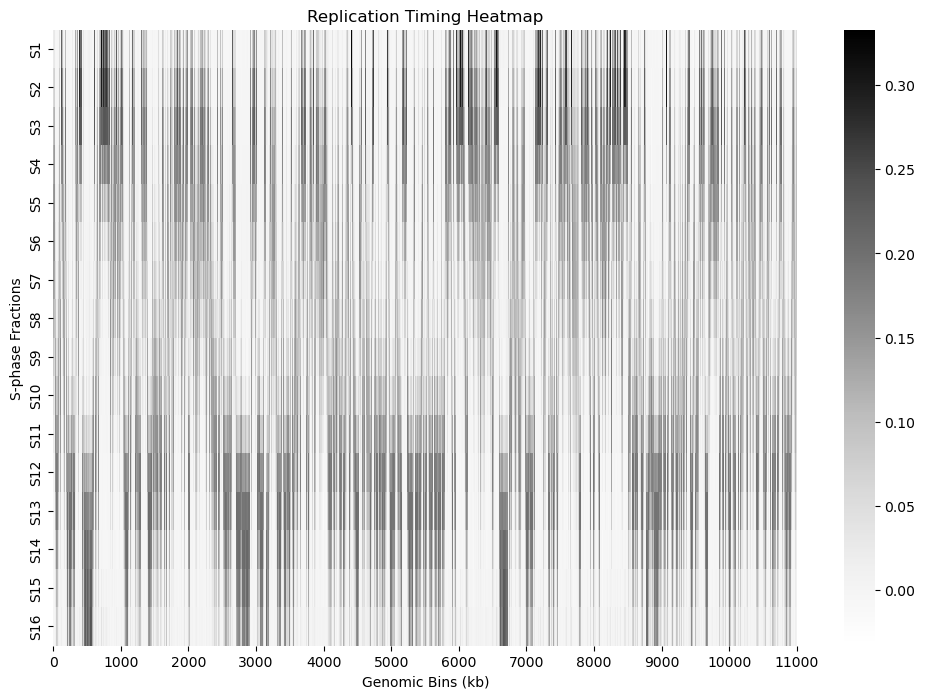

In [16]:
plt.figure(figsize=(12, 8))
ax = sns.heatmap(y_pred_transposed, cmap='Greys', cbar=True, xticklabels=1000, yticklabels=[f"S{i+1}" for i in range(16)])
ax.set_xlabel("Genomic Bins (kb)")
ax.set_ylabel("S-phase Fractions")
plt.title("Replication Timing Heatmap")
plt.show()

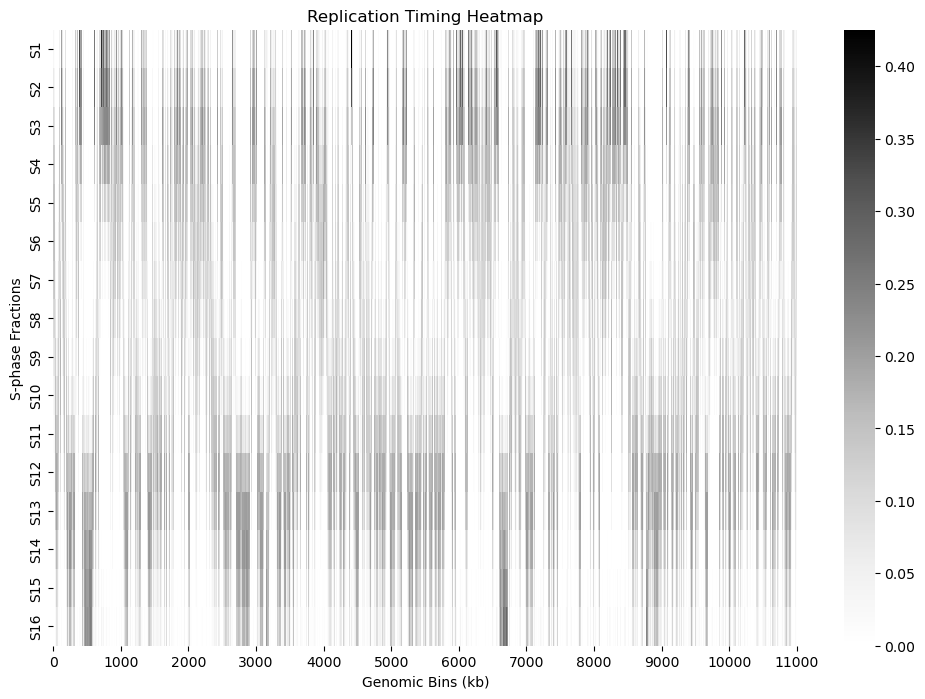

In [17]:
plt.figure(figsize=(12, 8))
ax = sns.heatmap(y_true_transposed, cmap='Greys', cbar=True, xticklabels=1000, yticklabels=[f"S{i+1}" for i in range(16)])
ax.set_xlabel("Genomic Bins (kb)")
ax.set_ylabel("S-phase Fractions")
plt.title("Replication Timing Heatmap")
plt.show()